In [1]:
import numpy as np
import xarray as xr

import pandas as pd
import matplotlib.pyplot as plt
from pyspectrum import Spectrum, TimeChannelParser, germanium_fwhm
from pyspectrum import Peak, FindPeaksDomain, Convolution
from uncertainties import ufloat, std_dev, nominal_value
from uncertainties.unumpy import nominal_values, std_devs, uarray

load the spectrum

In [2]:
time_channel_df = pd.read_csv('../Library/Doppler_broadening_Spectrum.txt', skiprows=5, sep=' ', names=['time', 'channel', 'flag'], usecols=range(3))

In [3]:
energy_calib_poly_det_1 = np.poly1d([0.0408976444, 0.0822321508])

energy_resolution_det_1 = 1.05 

estimated_FWHM_det_1 = lambda energy: germanium_fwhm(energy, 0, energy_resolution_det_1/511**0.5, 0)

In [4]:
spectrum = TimeChannelParser.to_spectrum(time_channel_df=time_channel_df, energy_calibration_poly=energy_calib_poly_det_1, fwhm_calibration=estimated_FWHM_det_1)

(300.0, 700.0)

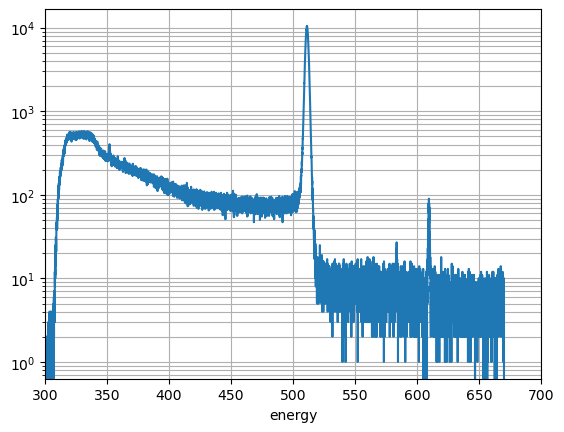

In [5]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.xlim([300,700])

let's find the peak domain

In [6]:
conv = Convolution(width=estimated_FWHM_det_1)
fp = FindPeaksDomain(spectrum=spectrum, convolution=conv, n_sigma_threshold=6)

Find the peak domain

In [7]:
domain = fp.peaks_domain(511)
annihilation_peak = spectrum[domain[0]:domain[1]]

Text(0, 0.5, 'counts')

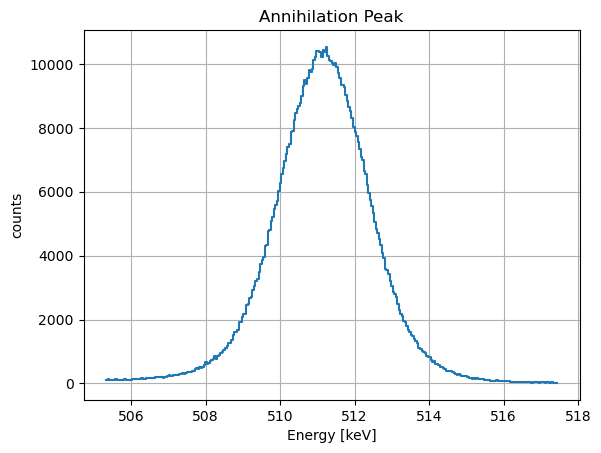

In [8]:
annihilation_peak.plot.step()
plt.grid(True, which='both')
plt.title('Annihilation Peak')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

Define the peak

In [9]:
r_bg = ufloat(annihilation_peak[-6:-1].mean().item(), annihilation_peak[-6:-1].std().item())
l_bg = ufloat(annihilation_peak[:6].mean().item(), annihilation_peak[:6].std().item())
peak = Peak(peak_xarray=annihilation_peak, ubackground_l=l_bg, ubackground_r=r_bg)

it has some properties

In [11]:
peak.estimated_center, peak.estimated_resolution

(511.19857598225093, 2.658346886000004)

and the background propeties

In [12]:
peak.height_left, peak.height_right

(109.33333333333333+/-8.806563209081938, 28.4+/-6.740919818541088)

# we can do some operation on the peak
It's approximatly behaves like an xarray

In [13]:
time = 493978
normlized_peak = (peak/time)

Text(0, 0.5, 'cps')

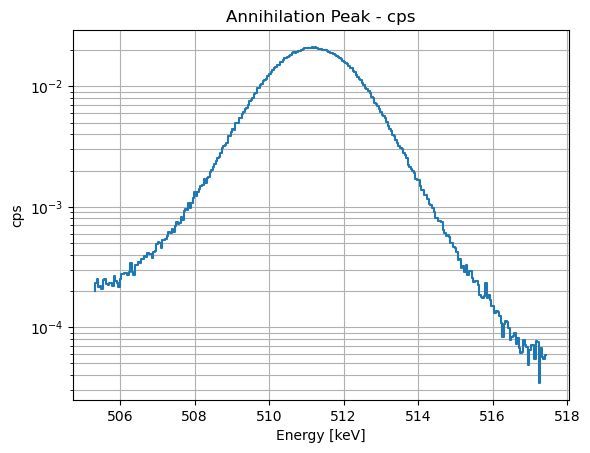

In [14]:
normlized_peak.plot.step(yscale='log')
plt.grid(True, which='both')
plt.title('Annihilation Peak - cps')
plt.xlabel('Energy [keV]')
plt.ylabel('cps')

and as some methods

In [15]:
normlized_peak.first_moment_method_center()

511.1951040089746+/-1.0466778527401686

Text(0, 0.5, 'cps')

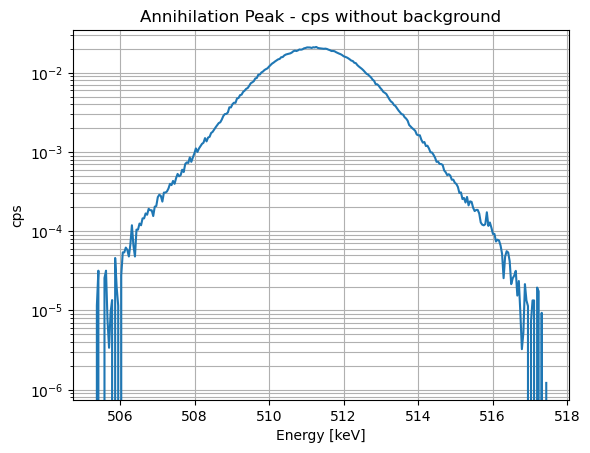

In [16]:
plt.semilogy(normlized_peak.channel, nominal_values(normlized_peak.subtract_background()))
plt.grid(True, which='both')
plt.title('Annihilation Peak - cps without background')
plt.xlabel('Energy [keV]')
plt.ylabel('cps')

The propeties are also updated

In [17]:
normlized_peak.height_left, normlized_peak.height_right

(0.0002213323940202465+/-1.7827844983140824e-05,
 5.749243893452745e-05+/-1.3646194402465472e-05)